<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/VideoAnalysis/VideoAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python numpy deepface


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=6dc4f963f5972afc6571696dc58649290f5649040a93e667ff8916ebeaea2dbc
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


Detected Emotion: happy
Face Proportion in Image: 1.07%


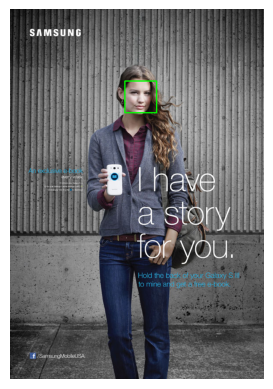

In [3]:
import cv2
import numpy as np
from deepface import DeepFace

# Load image
image_path = "/content/Samsung poster.jpg"  # Change this to your image path
image = cv2.imread(image_path)

# Load OpenCV face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Get image dimensions
img_height, img_width = image.shape[:2]

# Analyze each face
for (x, y, w, h) in faces:
    # Draw rectangle around the face
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Calculate face size proportion
    face_area = w * h
    image_area = img_width * img_height
    face_proportion = face_area / image_area

    # Crop face region for emotion detection
    face_crop = image[y:y+h, x:x+w]

    # Save cropped face as temp file
    face_temp_path = "temp_face.jpg"
    cv2.imwrite(face_temp_path, face_crop)

    # Analyze emotion using DeepFace
    analysis = DeepFace.analyze(face_temp_path, actions=['emotion'], enforce_detection=False)
    emotion = analysis[0]['dominant_emotion']

    print(f"Detected Emotion: {emotion}")
    print(f"Face Proportion in Image: {face_proportion:.2%}")

# Display the image with face rectangle
import matplotlib.pyplot as plt

# Convert image from BGR (OpenCV format) to RGB (Matplotlib format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis("off")  # Hide axis
plt.show()



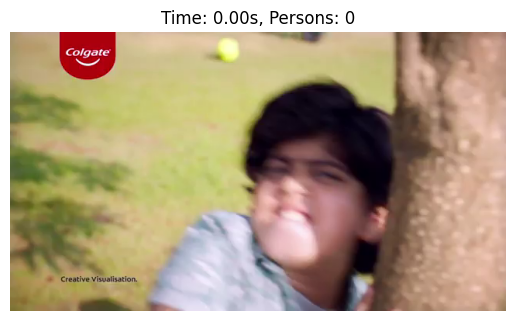

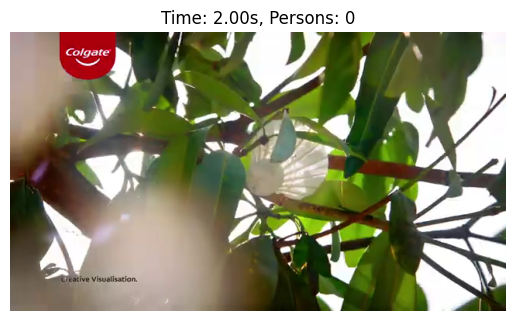

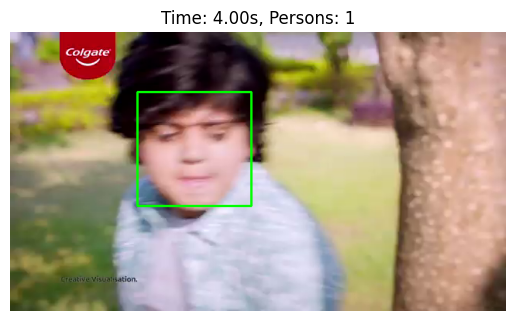

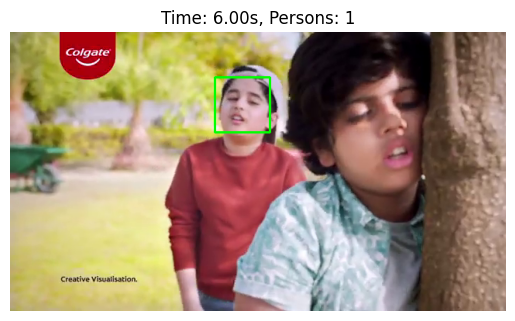

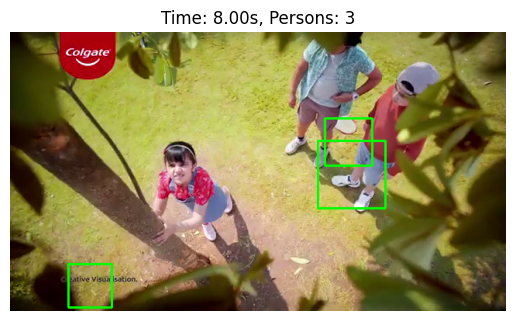

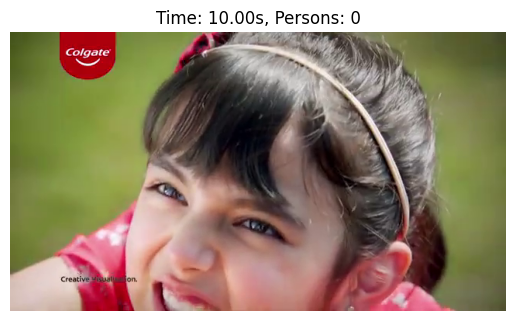

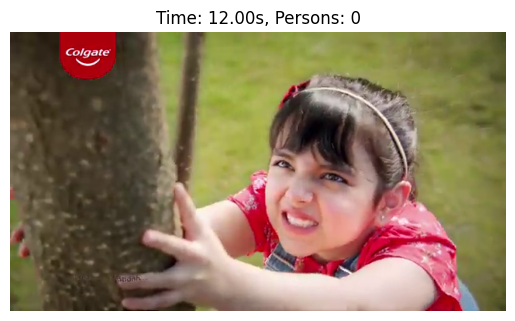

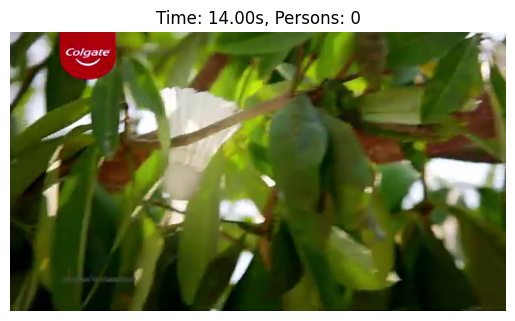

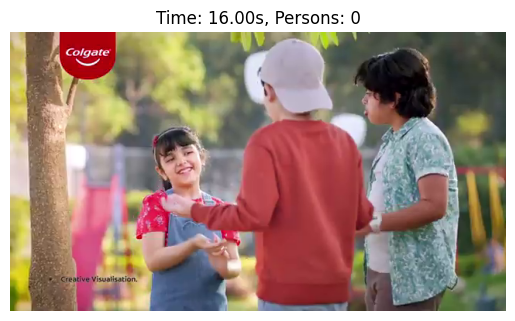

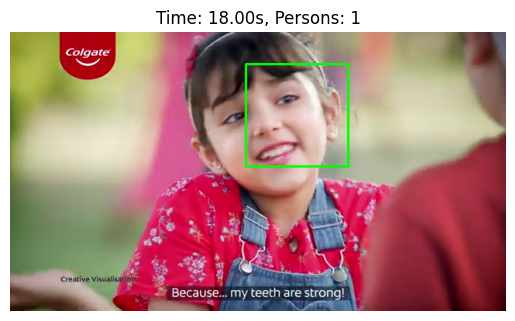

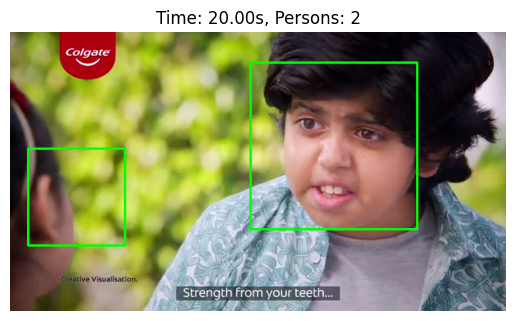

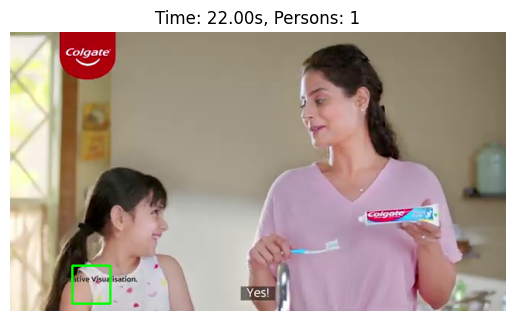

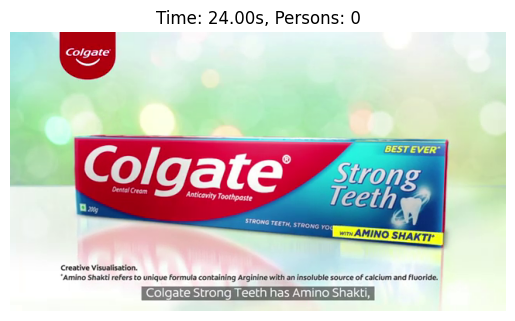

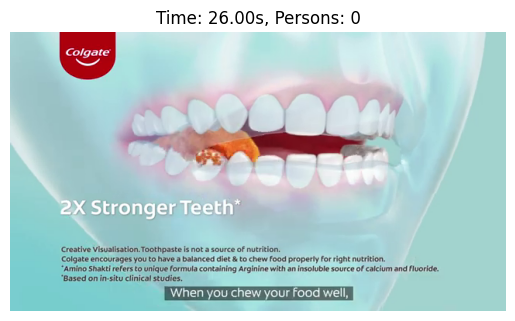

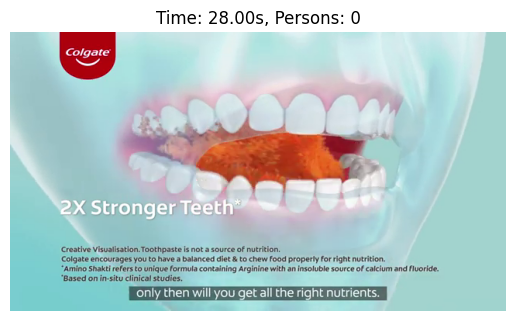

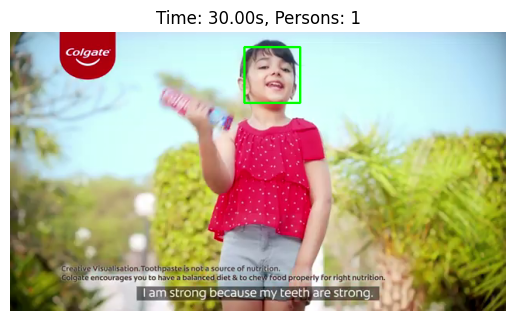

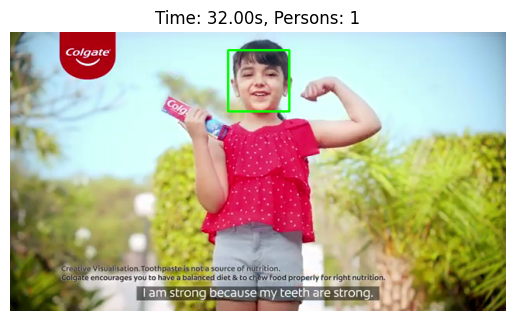

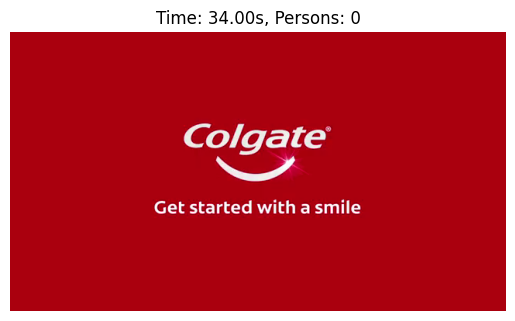

Analysis completed! Results saved in 'emotion_trend.xlsx'


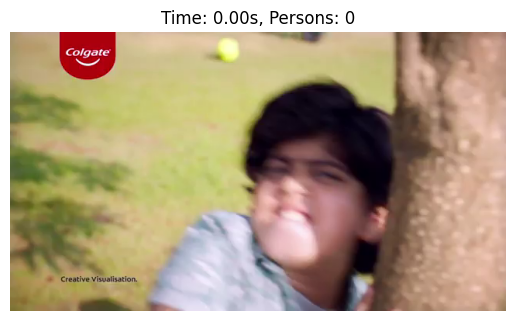

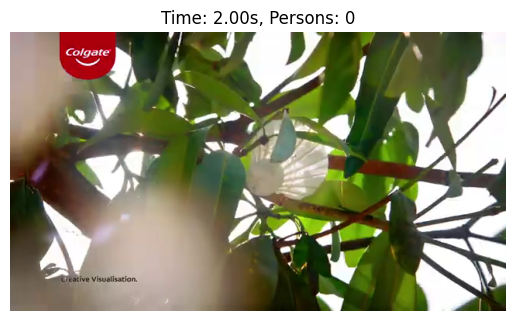

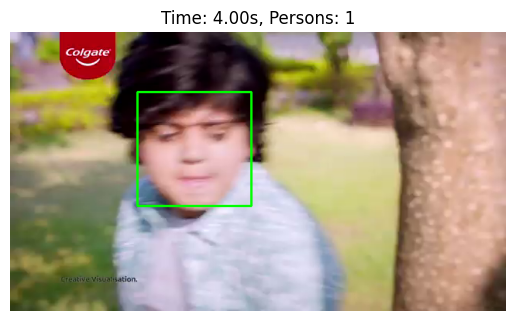

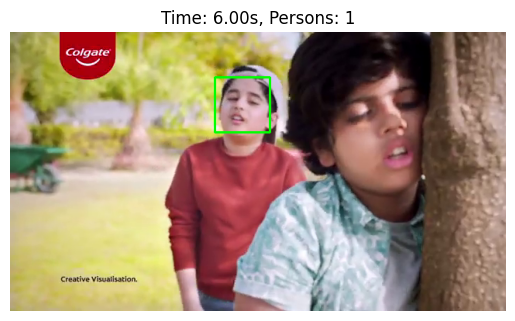

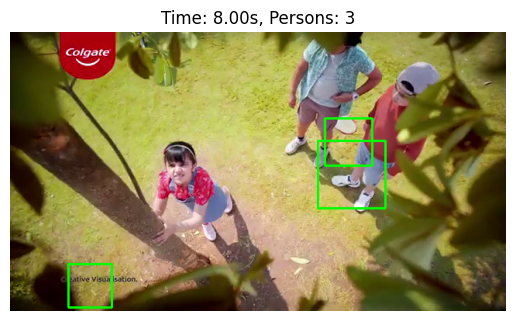

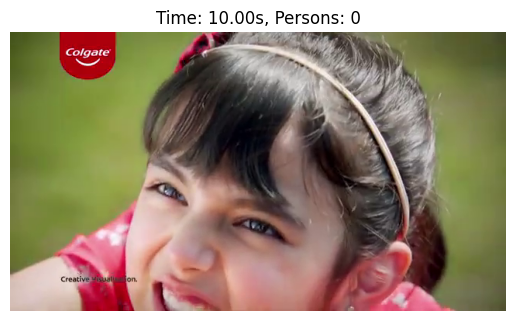

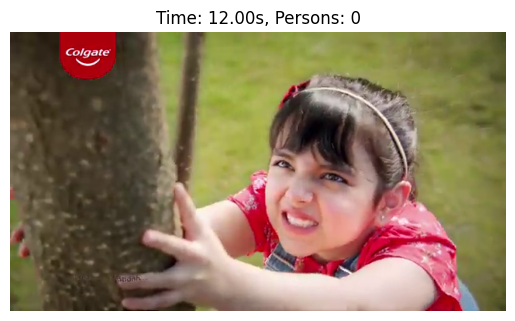

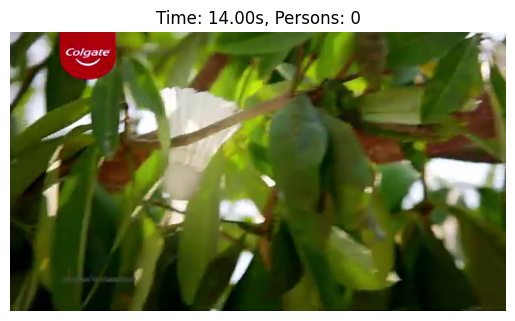

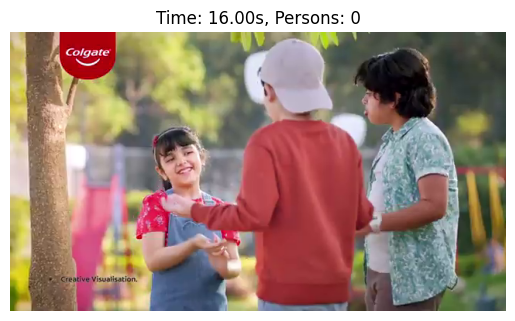

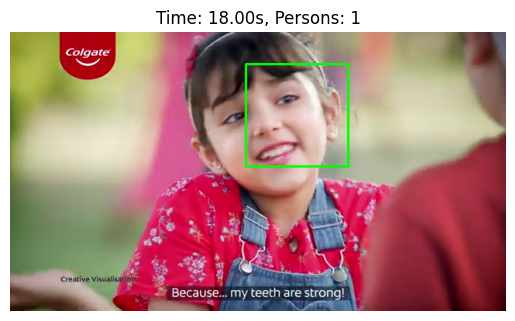

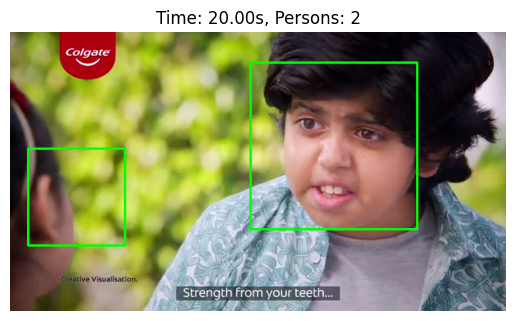

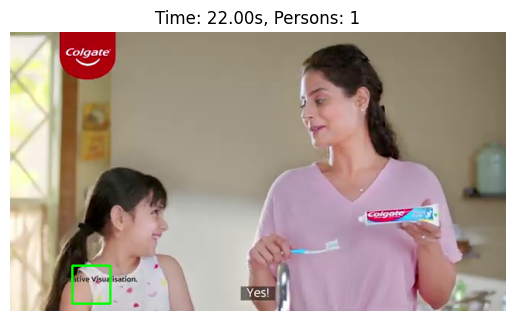

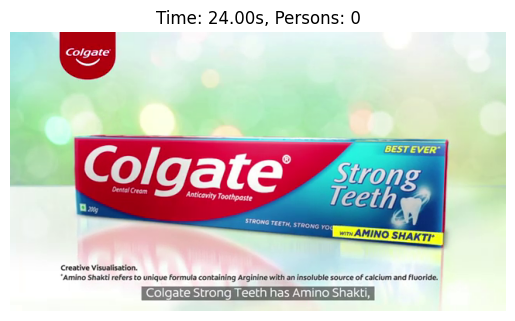

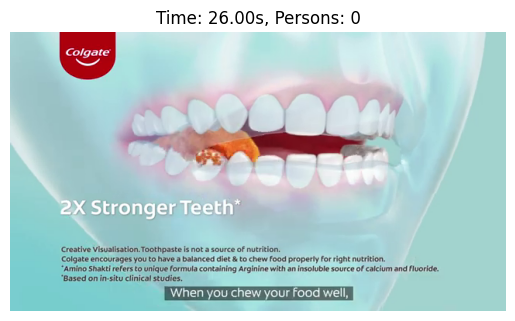

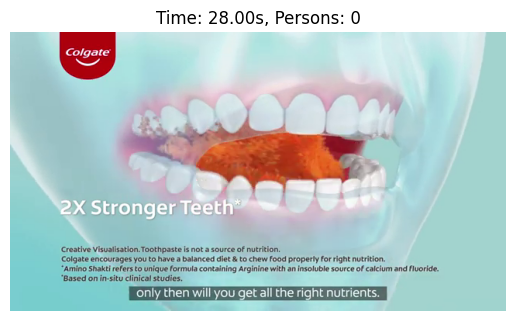

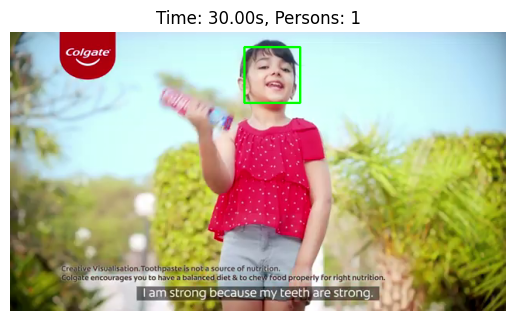

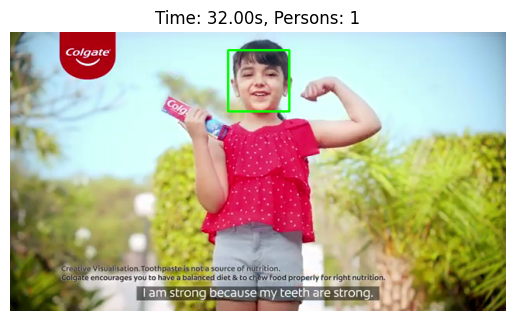

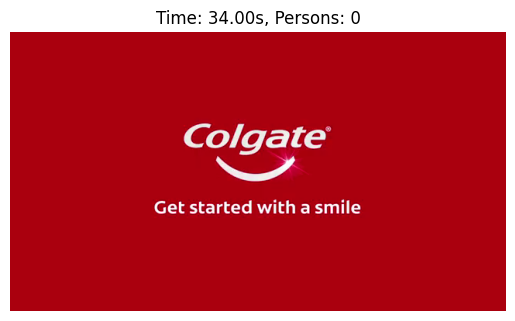

Analysis completed! Results saved in 'emotion_trend.xlsx'


In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from deepface import DeepFace

# Load the face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Load the video
video_path = "/content/Colgate Strong Teeth _ Daant Strong Toh Main Strong _ English.mp4"  # Change to your video file
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))  # Frames per second
frame_interval = fps * 2  # Process every 2 seconds
frame_count = 0

# Data storage
emotion_data = []

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break  # Exit if video ends

    # Process every 2 seconds
    if frame_count % frame_interval == 0:
        time_stamp = frame_count / fps  # Time in seconds

        # Convert frame to grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

        # Store emotions for this frame
        frame_emotions = []

        for (x, y, w, h) in faces:
            # Draw rectangle around face
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # Crop the detected face
            face_crop = frame[y:y+h, x:x+w]

            # Save temp face image
            face_temp_path = "temp_face.jpg"
            cv2.imwrite(face_temp_path, face_crop)

            # Emotion analysis using DeepFace
            try:
                analysis = DeepFace.analyze(face_temp_path, actions=['emotion'], enforce_detection=False)
                emotion = analysis[0]['dominant_emotion']
            except:
                emotion = "unknown"

            # Store data
            frame_emotions.append(emotion)
            emotion_data.append([time_stamp, len(faces), emotion])

        # Display frame with bounding boxes
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame_rgb)
        plt.axis("off")
        plt.title(f"Time: {time_stamp:.2f}s, Persons: {len(faces)}")
        plt.show()

    frame_count += 1  # Increase frame count

# Release video capture
cap.release()
cv2.destroyAllWindows()

# Save data to Excel
df = pd.DataFrame(emotion_data, columns=["Time (s)", "Number of Persons", "Emotion"])
df.to_excel("emotion_trend.xlsx", index=False)

print("Analysis completed! Results saved in 'emotion_trend.xlsx'")
